# Symmetry class of Kitaev chain

Consider the spinless Kitaev chain model
$$H = \sum_{j=1}^{L} - t_j (c_{j+1}^{\dag}c_j + \text{h.c.}) - \mu c_j^{\dag} c_j + (\Delta e^{i\theta} c_j c_{j+1} + \text{h.c.}),$$
this automatically has particle-hole symmetry. Now set $\theta=0,\pi$ to make all coefficients real, this gives time-reversal symmetry (invariant under complex conjugation). Hvaing both PH and T symmetry automatically gives chiral symmetry. Hence, the system with $\theta=0,\pi$ is in class BDI and has a $\mathbb{Z}$ invariant.

Consider $\theta \neq 0, \pi$, this breaks T symmetry which also results in the breaking of chiral symmetry. This moves the system to class D with a $\mathbb{Z}_2$ invariant as expected by Majorana Polarisation.

All my previous simulations have taken $\theta=0$ and recovered notions of $a \mathbb{Z}_2$ invariant in the MP classification. Notably, there was some ambiguity about the definiton of MP. MP is defined as $\mathcal{M} = P_L \cdot P_R^* = P_L^* \cdot P_R$, where
\begin{equation}
    \begin{split}
        % \mathcal{M} &= P_L \cdot P_R^* = P_L^* \cdot P_R \ (= P_L \cdot P_R), \\
        % \text{where}, \\   
        P_L &= \frac{\sum_{j=1}^{L/2} \bra{\psi_{j,n}} \hat{C} \ket{\psi_{j,n}}}{\sum_{j=1}^{L/2} \braket{\psi_{j,n} | \psi_{j,n}}} \\
        P_R &= \frac{\sum_{j=(L/2)+1}^{L} \bra{\psi_{j,M-n}} \hat{C} \ket{\psi_{j,M-n}}}{\sum_{j=(L/2)+1}^{L} \braket{\psi_{j,M-n} | \psi_{j,M-n}}}.
    \end{split}
\end{equation}
which seems to require the importance of measuring one Majorana state on the left against the other Majorana state on the right. In fact, I observed that when $\theta=0$ the same Majorana state could be compared between the left and right and recover the same MP result as comparing different Majoranas. Moreover, the complex conjugation in the defininton of $\mathcal{M}$ was not needed as all components were real.

The question is, does proper consideration of $\theta \neq 0, \pi$ result in the expected MP relationships? Importantly, is this the only information I have lost whilst taking $\theta=0$ in all previous simulations? Therefore, is it reasonable to take $\theta=0$ without loss of genereality of numerical results?

If not, and there is a substantive difference made by taking $\theta \neq 0, \pi$ previous simulations will need to be re-run with this additional degree of freedom.

## Some notes on $\theta$

The $\theta$ degree of freedom is not equivalent to the phason angle. Varying $\theta$ controls the Andreev bound state energies in the SC gap. Varying $\phi$ controls the bulk subgap state energies in the QC gaps. This would maek sense with observations of winding in all gaps other than the SC gap when varying $\phi$. This script will explore the effect of varying $\theta$ on winding.

In [9]:
using Plots
using LinearAlgebra
using DataFrames
using ProgressMeter

golden_ratio = (1 + sqrt(5)) / 2

1.618033988749895

In [10]:
function cut_and_project_sequence(N::Int, gamma::Float64; phi::Float64=0.0, map_to::Tuple{Int,Int}=(1,2))
    @assert N >= 1 "N must be >= 1"
    # @assert 0.0 < gamma < 1.0 "gamma expected in (0,1) for standard Sturmian words"
    phi = phi - floor(phi) # wrap into [0,1)
    seq = Vector{Int}(undef, N)
    frac = phi
    for n in 1:N
        frac += gamma
        if frac >= 1.0
            frac -= 1.0
            # crossing an integer -> difference = 1
            seq[n] = map_to[1]   # "A"
        else
            seq[n] = map_to[2]   # "B"
        end
    end
    return seq
end

gamma = 1 / golden_ratio
N = 1000
phi = gamma
golden_seq = cut_and_project_sequence(N, gamma; phi=phi, map_to=(1,2))
println("done")

done


In [22]:
function create_bdg_hamiltonian(
    N::Int, 
    t_n::Vector,
    mu::Float64, 
    Delta::Float64,
    theta::Float64,
    sequence::Vector
)
    Delta = Delta * exp(1im * theta) # N.B. sign convension difference between this and equation at top
    H0 = zeros(Complex{Float64}, N, N)
    for i in 1:N-1
        H0[i, i] = -mu
        hopping_index = sequence[i]
        H0[i, i+1] = -t_n[hopping_index]
        H0[i+1, i] = -t_n[hopping_index]
    end
    H0[N, N] = -mu

    Delta_matrix = zeros(Complex{Float64}, N, N)
    for i in 1:N-1
        Delta_matrix[i, i+1] = Delta
        Delta_matrix[i+1, i] = -Delta
    end

    BdG = zeros(Complex{Float64}, 2N, 2N)
    BdG[1:N, 1:N] = H0
    BdG[N+1:end, N+1:end] = -conj(H0)
    BdG[1:N, N+1:end] = Delta_matrix
    BdG[N+1:end, 1:N] = Delta_matrix'

    return BdG
end
function calc_maj_mp(
    eigenvectors::Matrix{ComplexF64}
)
    num_rows = size(eigenvectors, 1)
    N = num_rows ÷ 2
    middle_state_index = N

    # We are interested in the two states closest to zero energy: N and N+1
    state_indices = [middle_state_index, middle_state_index + 1]
    
    # The keys will be (state_index_L - middle, state_index_R - middle)
    # e.g., (0,0), (0,1), (1,0), (1,1)
    results = Dict{Tuple{Int, Int}, Tuple{ComplexF64, ComplexF64, ComplexF64, ComplexF64, ComplexF64}}()

    for idx_L in state_indices
        for idx_R in state_indices
            
            # --- Calculate P_L using only state idx_L ---
            u_L = eigenvectors[1:N, idx_L]
            v_L = eigenvectors[(N+1):2N, idx_L]
            
            # numerator_L = sum(u_L[i] * conj(v_L[i]) + v_L[i] * conj(u_L[i]) for i in 1:(N÷2))
            # denominator_L = sum(abs2(u_L[i]) + abs2(v_L[i]) for i in 1:(N÷2))
            # MP_L = numerator_L / denominator_L
            # REVISED FORMULA:
            numerator_L = sum(2 * u_L[i] * conj(v_L[i]) for i in 1:(N÷2))
            denominator_L = sum(abs2(u_L[i]) + abs2(v_L[i]) for i in 1:(N÷2))
            MP_L = numerator_L / denominator_L

            # --- Calculate P_R using only state idx_R ---
            u_R = eigenvectors[1:N, idx_R]
            v_R = eigenvectors[(N+1):2N, idx_R]
            
            # numerator_R = sum(u_R[i] * conj(v_R[i]) + v_R[i] * conj(u_R[i]) for i in ((N÷2)+1):N)
            # denominator_R = sum(abs2(u_R[i]) + abs2(v_R[i]) for i in ((N÷2)+1):N)
            # MP_R = numerator_R / denominator_R
            # REVISED FORMULA:
            numerator_R = sum(2 * u_R[i] * conj(v_R[i]) for i in ((N÷2)+1):N)
            denominator_R = sum(abs2(u_R[i]) + abs2(v_R[i]) for i in ((N÷2)+1):N)
            MP_R = numerator_R / denominator_R

            # --- Combine them ---
            MP1 = conj(MP_L) * MP_R
            MP2 = conj(MP_R) * MP_L
            MP3 = MP_L * MP_R

            # Store results keyed by which states were used for L and R respectively
            key_L = idx_L - middle_state_index 
            key_R = idx_R - middle_state_index

            results[(key_L, key_R)] = (ComplexF64(MP_L), ComplexF64(MP_R), MP1, MP2, MP3)
        end
    end
    
    return results
end

function simple_solver(
    N::Int,
    t_n::Vector,
    mu::Float64,
    Delta::Float64,
    theta::Float64,
    sequence::Vector
)
    BdG = create_bdg_hamiltonian(N, t_n, mu, Delta, theta, sequence)
    evals, evecs = eigen(BdG)
    maj_mp_results = calc_maj_mp(evecs)
    return evals, maj_mp_results
end

simple_solver (generic function with 1 method)

In [23]:
N = 100
t_n = [1.0, 1.5]
mu_range = 0.0:0.1:3.0
Delta = 0.1
# theta = 0.1
theta_range = 0.0:π/10:2π
sequence = golden_seq

df = DataFrame(
    N = Int[],
    t_n = Vector{Float64}[],
    mu = Float64[],
    Delta = Float64[],
    theta = Float64[],
    eigenvalues = Vector{ComplexF64}[],
    maj_mp_results = Dict{Tuple{Int, Int}, Tuple{ComplexF64, ComplexF64, ComplexF64, ComplexF64, ComplexF64}}[] # Column for the results dict
)

@showprogress for mu in mu_range
    for theta in theta_range
        evals, maj_mp_results = simple_solver(
            N,
            t_n,
            mu,
            Delta,
            theta,
            sequence
        )
        push!(df, (N, t_n, mu, Delta, theta, evals, maj_mp_results))
    end
end
println("Calculation complete")

Progress: 100%|█████████████████████████████████████████| Time: 0:00:09


Calculation complete


In [35]:
function plt_eigenvalues_generalised(df::DataFrame, x_variable::Symbol; fixed_values...)
    """
    Plots eigenvalues as a function of a specified variable from the DataFrame.
    Scales to complex numbers by plotting Real and Imag parts side-by-side.

    Parameters:
    df           -- DataFrame containing the data.
    x_variable   -- Symbol representing the variable to plot on the x-axis.
    fixed_values -- Keyword arguments specifying fixed values for all other DataFrame columns.
    """

    filtered_df = filter(row -> all(getproperty(row, key) == value for (key, value) in fixed_values), df)

    if isempty(filtered_df)
        error("No results match the specified fixed values.")
    end

    x_values = filtered_df[:, x_variable]
    all_eigenvalues = filtered_df[:, :eigenvalues]
    num_eigenvalues = length(all_eigenvalues[1])

    # Plot 1: Real Part
    p_real = Plots.scatter(
        legend=false, 
        xlabel=string(x_variable), 
        ylabel="Real(E)", 
        title="Real Part",
        grid=true
    )

    # Plot 2: Imaginary Part
    p_imag = Plots.scatter(
        legend=false, 
        xlabel=string(x_variable), 
        ylabel="Imag(E)", 
        title="Imaginary Part",
        grid=true
    )

    for i in 1:num_eigenvalues
        # Extract the i-th eigenvalue from every simulation in the filtered set
        eigenvalue_line = [eigenvalues[i] for eigenvalues in all_eigenvalues]
        
        plot!(p_real, x_values, real.(eigenvalue_line), markersize=2, markerstrokewidth=0, color=:blue)
        plot!(p_imag, x_values, imag.(eigenvalue_line), markersize=2, markerstrokewidth=0, color=:red)
    end

    # Combine them into a single layout
    layout = plot(p_real, p_imag, layout=(1, 2), size=(900, 500))
    Plots.display(layout)
    # Plots.savefig(layout, "eigenvalues_vs_$(x_variable)_theta$(fixed_values[:theta]).png")
end

function plt_mp_comparison(df::DataFrame, x_variable::Symbol; fixed_values...)
    """
    Plots MP results for each key combination (key_u, key_v).
    Generates 4 plots per key combo:
      1. Real(MP_L) & Real(MP_R)
      2. Imag(MP_L) & Imag(MP_R)
      3. Real(MP1), Real(MP2), Real(MP3)
      4. Imag(MP1), Imag(MP2), Imag(MP3)
    """

    # 1. Filter DataFrame
    filtered_df = filter(row -> all(getproperty(row, key) == value for (key, value) in fixed_values), df)
    
    if isempty(filtered_df)
        error("No results match the specified fixed values.")
    end

    x_values = filtered_df[:, x_variable]
    all_results = filtered_df[:, :maj_mp_results]

    # Get the available keys from the first result dictionary
    # Assuming all entries have the same keys
    available_keys = keys(first(all_results))

    for key_combo in available_keys
        # Prepare arrays to hold data for this key combination across all simulations
        mp_l_list = ComplexF64[]
        mp_r_list = ComplexF64[]
        mp1_list = ComplexF64[]
        mp2_list = ComplexF64[]
        mp3_list = ComplexF64[]

        # Extract data for this specific (key_u, key_v)
        for res_dict in all_results
            # res_dict[key_combo] returns (MP_L, MP_R, MP1, MP2, MP3)
            vals = res_dict[key_combo]
            push!(mp_l_list, vals[1])
            push!(mp_r_list, vals[2])
            push!(mp1_list, vals[3])
            push!(mp2_list, vals[4])
            push!(mp3_list, vals[5])
        end

        # --- Create plots ---
        title_common = "Key: $key_combo"

        # Plot 1: Real parts of MP_L and MP_R
        p1 = plot(
            x_values, [real.(mp_l_list) real.(mp_r_list)],
            label=["Re(L)" "Re(R)"],
            title="$title_common - Real(L/R)",
            xlabel=string(x_variable), ylabel="Amplitude",
            markersize=2, markerstrokewidth=0
        )

        # Plot 2: Imaginary parts of MP_L and MP_R
        p2 = plot(
            x_values, [imag.(mp_l_list) imag.(mp_r_list)],
            label=["Im(L)" "Im(R)"],
            title="$title_common - Imag(L/R)",
            xlabel=string(x_variable), ylabel="Amplitude",
            markersize=2, markerstrokewidth=0
        )

        # Plot 3: Real parts of MP1, MP2, MP3
        p3 = plot(
            x_values, [real.(mp1_list) real.(mp2_list) real.(mp3_list)],
            label=["Re(MP1)" "Re(MP2)" "Re(MP3)"],
            title="$title_common - Real(MP1/2/3)",
            xlabel=string(x_variable), ylabel="Amplitude",
            markersize=2, markerstrokewidth=0
        )

        # Plot 4: Imaginary parts of MP1, MP2, MP3
        p4 = plot(
            x_values, [imag.(mp1_list) imag.(mp2_list) imag.(mp3_list)],
            label=["Im(MP1)" "Im(MP2)" "Im(MP3)"],
            title="$title_common - Imag(MP1/2/3)",
            xlabel=string(x_variable), ylabel="Amplitude",
            markersize=2, markerstrokewidth=0
        )

        # Combine into a 2x2 layout
        final_layout = plot(p1, p2, p3, p4, layout=(2, 2), size=(1000, 800))
        # display(final_layout)
        Plots.savefig(final_layout, "results/theta_dependence/mp_vs_mu/mp_plots_key_$(key_combo[1])_$(key_combo[2])_theta_$(fixed_values[:theta]).png")
    end
end

plt_mp_comparison (generic function with 1 method)

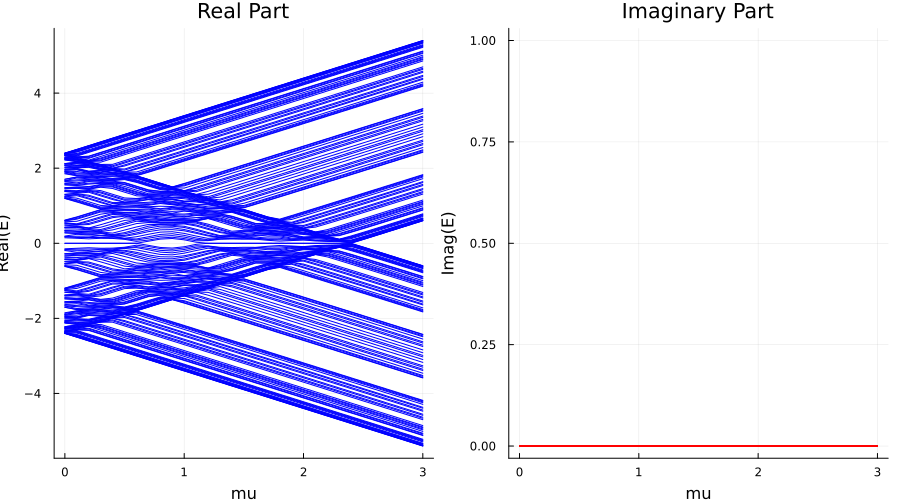

In [25]:
theta=0.0
plt_eigenvalues_generalised(
    df, 
    :mu;
    theta=theta
)

Plotting MP comparison for theta = 0.0


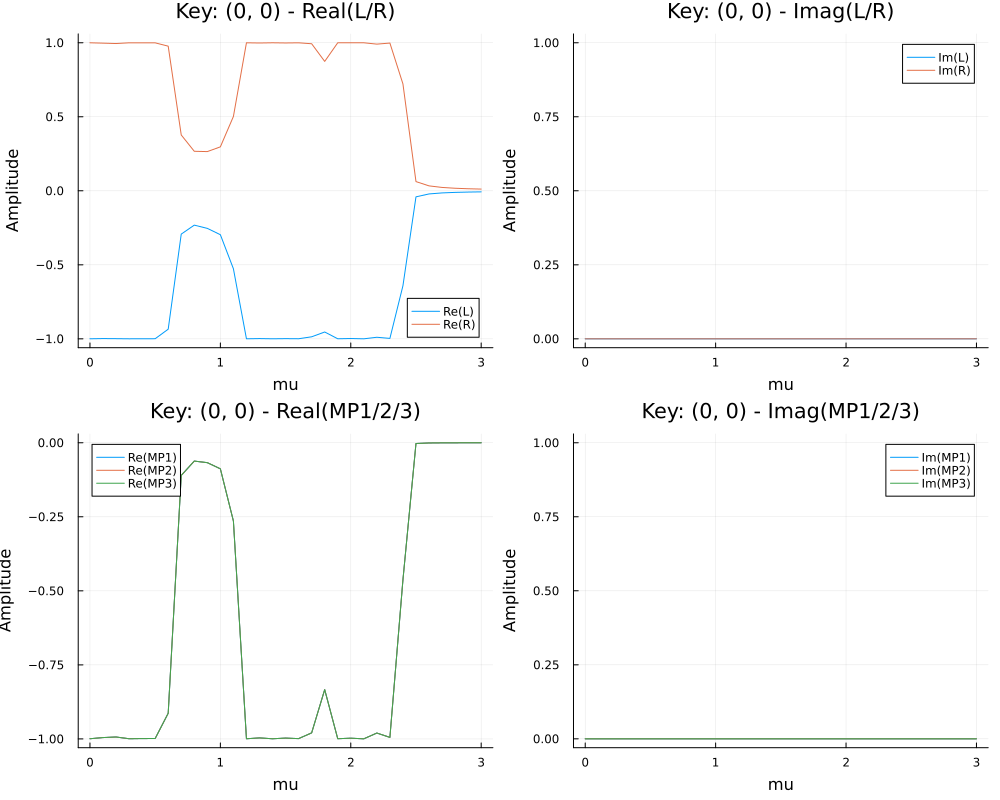

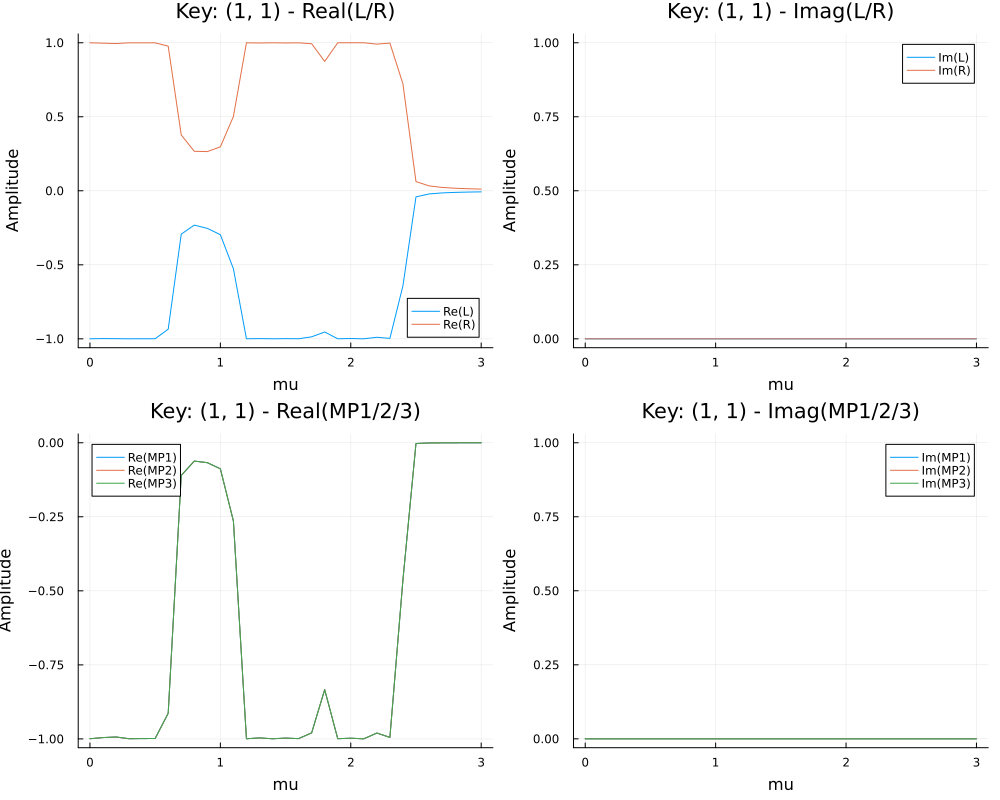

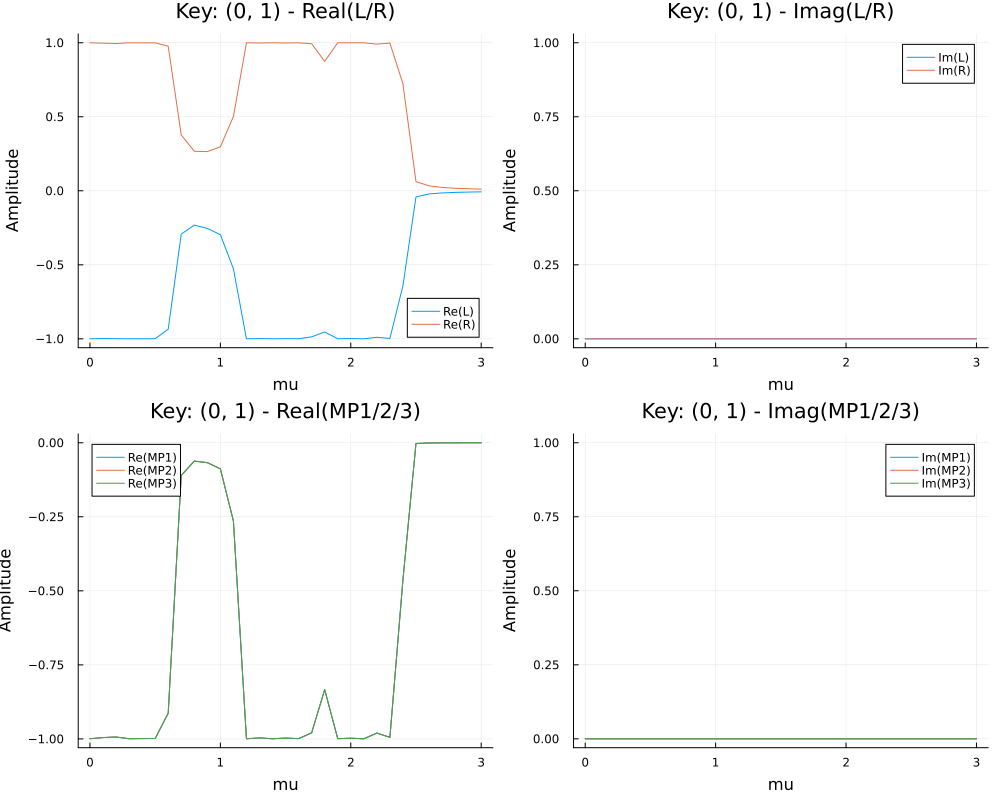

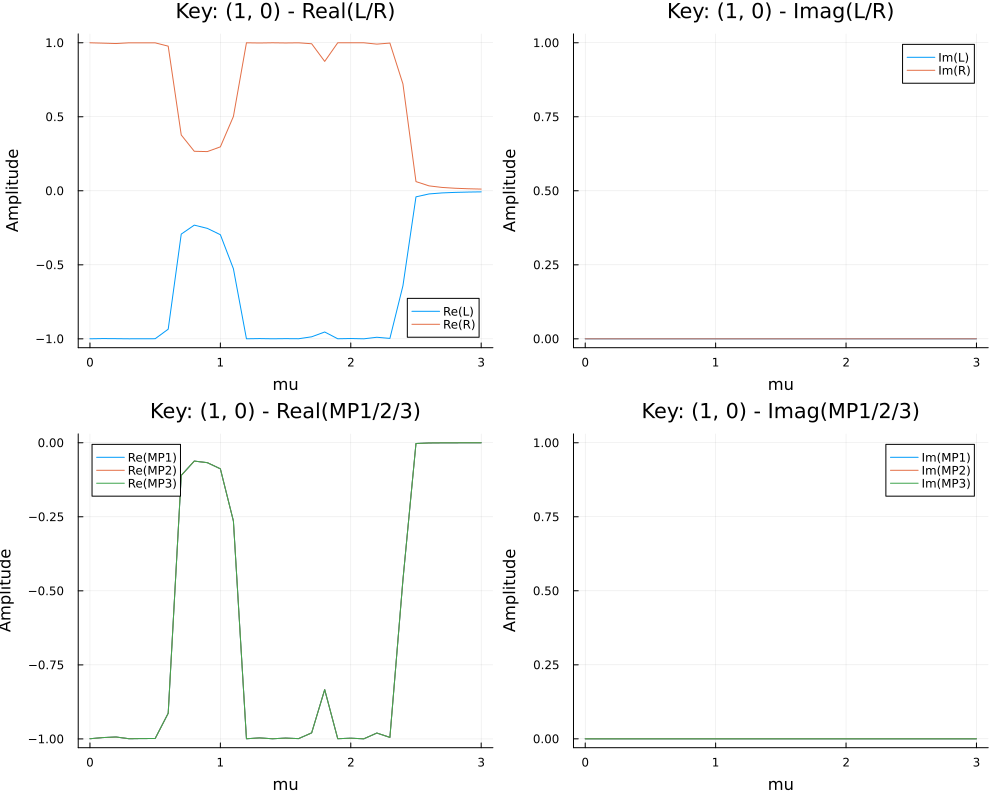

In [34]:
theta = theta_range[1]
println("Plotting MP comparison for theta = $theta")
plt_mp_comparison(
    df,
    :mu;
    theta=theta
)

In [36]:
for theta in theta_range
    # plt_eigenvalues_generalised(
    #     df, 
    #     :mu,
    #     theta=theta
    # )
    
    plt_mp_comparison(
        df,
        :mu,
        theta=theta
    )
end

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict

## Observations

Vayring $\theta$ has no effect on the eiganvlaues -- these remain real, can see now winding.

Now, questioning the calculation of MP under $\theta \neq 0, \pi$ we see that no matter the combination of eigenstates compared the outcome is the same. That is to say, when both MP_L and MP_R are both calculated on the $N^\text{th}$ eigenstate this looks the same (same MP_L and MP_R curves) as when MP_L is calculated on the $N^\text{th}$ and MP_R on the $N+1^\text{th}$ eigenstate. This isn't intuitive to me. I imagine the components of one eigenstate to be drastically different -- localised to one half of the chain -- than the other PH symmetric eigenstate.

One suggestion is this:

Why $P_L$ and $P_R$ are Invariant
Let's look at the calculation of $P_L$ for these two states.
*   **State $N+1$:** $P_L(N+1) = \sum_{Left} 2 u_{N+1} v_{N+1}^*$.
*   **State $N$:** The components of state $N$ are related to $N+1$ by PH symmetry.
    *   $u_N = v_{N+1}^*$
    *   $v_N = u_{N+1}^*$
*   **Calculating $P_L(N)$:**
    $$ 2 u_N v_N^* = 2 (v_{N+1}^*) (u_{N+1}^*)^* = 2 v_{N+1}^* u_{N+1} = (2 u_{N+1} v_{N+1}^*)^* $$

So, $P_L(N)$ is simply the **complex conjugate** of $P_L(N+1)$.

However, both $P_L$ and $P_R$ undergo this conjugation.
*   Comparison 1 ($N$ vs $N$): $P_L(N) P_R(N)^* \sim P_L^* P_R$
*   Comparison 2 ($N+1$ vs $N+1$): $P_L(N+1) P_R(N+1)^* \sim P_L P_R^*$
*   Comparison 3 ($N$ vs $N+1$): $P_L(N) P_R(N+1)^* \sim P_L^* P_R^*$

Since we are looking at the **magnitude** of the polarization (invariant under conjugation) or the product forms $MP_1, MP_2$, they will fundamentally describe the same physical correlations, just potentially with sign flips or phase conjugations depending on exactly how the solver resolves the degeneracy.

---------------------------------------------------------

Notably, this did confirm that $\mathcal{M} = P_L \cdot P_R^* = P_L^* \cdot P_R \neq P_L \cdot P_R$ for $\theta \neq 0, \pi$. The imaginary part of $P_L$ and $P_R$ follow the same form as the real part (gloablly scaled to different amplitude).

# Summary

This is a robust physical result arising from **Global Phase Cancellation**.

Here is the breakdown of why your Topological Invariant $\mathcal{M}$ remains Real and stable, even though the individual components ($P_L, P_R$) become complex and $\theta$-dependent.

### 1. Why $P_L$ and $P_R$ have Imaginary Parts
In the Hamiltonian, you introduced the term $\Delta e^{-i\theta} c^\dagger c^\dagger$. This attaches a complex phase to the creation of pairs.
As a result, the Majorana operators (which are superpositions of $c$ and $c^\dagger$) acquire a phase dependence. Roughly speaking, the Majorana states rotate in the complex plane:
$$ P_L(\theta) \approx P_L(0) \cdot e^{-i\theta} $$
$$ P_R(\theta) \approx P_R(0) \cdot e^{-i\theta} \quad (\text{assuming spatial symmetry}) $$
This explains why you see the Real and Imaginary parts of $P_L$ and $P_R$ evolving and winding as $\theta$ changes—they are carrying the gauge information of the superconductor.

### 2. Why the Product $\mathcal{M}$ is Always Real
The definition of the Majorana Polarization Invariant includes a complex conjugation:
$$ \mathcal{M} = P_L \cdot P_R^* $$
When you multiply these terms, the gauge dependencies cancel out exactly:
$$ \mathcal{M}(\theta) \approx ( P_L(0) e^{-i\theta} ) \cdot ( P_R(0) e^{-i\theta} )^* $$
$$ \mathcal{M}(\theta) \approx P_L(0) P_R(0) \cdot e^{-i\theta} e^{+i\theta} $$
$$ \mathcal{M}(\theta) \approx \text{Real Number} $$
This confirms that $\mathcal{M}$ is a **gauge-invariant observable**. It filters out the arbitrary superconducting phase $\theta$ to reveal the underlying topological protection (the overlap magnitude), which is why it remains purely Real.

### 3. Why the Keys (N vs N+1) Give Identical Results
You observed that Key(0,0) (N vs N) and Key(1,0) (N+1 vs N) give identical results. This algebraically confirms the previous point.

*   **Key(0,0):** Uses inputs $P_L(N)$ and $P_R(N)$. Recall $P(N) = P(N+1)^*$.
    $$ \mathcal{M}_{00} = P_L(N) P_R(N)^* = (L^*) (R^*)^* = L^* R $$
*   **Key(1,0):** Uses inputs $P_L(N+1)$ and $P_R(N)$.
    $$ \mathcal{M}_{10} = P_L(N+1) P_R(N)^* = L (R^*)^* = L R $$

If these plots appear identical (specifically the Real part of MP1), it implies that $L^* R = L R$.
This equality holds because the phase of $L$ cancels the phase of $R$ in the product, making the result Real. If a number is Real ($X \in \mathbb{R}$), then $X = X^*$.
Therefore, the invariance you are seeing is a direct confirmation that **particle-hole symmetry is enforcing the reality of the topological invariant**, rendering the choice of basis state ($N$ or $N+1$) irrelevant.